# Laboratorio 2 — Regresión (estilo del inge)
## Dataset: Contaminación 2000–2021

En este cuadernillo se entrena un modelo de regresión para predecir la variable objetivo `O3 ICA` a partir de múltiples características del dataset `contaminacion_2000_2021.csv`.

Se sigue el mismo flujo de los cuadernos del inge (carpeta `01 regresiones`):
- Normalización de características (`featureNormalize`)
- Descenso por gradiente multivariable (`gradientDescentMulti`)
- Ecuación normal (`normalEqn`)
- Variante polinómica: agregar potencias $x^2, x^3, ..., x^d$ sobre una característica

### Variables usadas
- `X`: matriz de características, forma $(m, n)$
- `y`: vector objetivo, forma $(m,)$
- `m`: número de ejemplos
- `n`: número de propiedades (características)

In [47]:
import numpy as np
import pandas as pd
from matplotlib import pyplot

In [48]:
dataset_path = 'contaminacion_2000_2021.csv'

df = pd.read_csv(dataset_path, sep=';')

columnas = [
    'Anio',
    'Mes',
    'Dia',
    'Estado',
    'Condado',
    'Ciudad',
    'O3 Promedio',
    'O3 Valor Maximo',
    'O3 Hora Maxima',
    'CO Promedio',
    'CO Valor Maximo',
    'CO Hora Maxima',
    'CO ICA',
    'SO2 Promedio',
    'SO2 Valor Maximo',
    'SO2 Hora Maxima',
    'SO2 ICA',
    'NO2 Promedio',
    'NO2 Valor Maximo',
    'NO2 Hora Maxima',
    'NO2 ICA',
    'O3 ICA',
 ]

df = df[columnas].copy()

# Convertir categóricas simples a números (dataset de contaminación tiene texto)
df['Estado'] = pd.factorize(df['Estado'])[0]
df['Condado'] = pd.factorize(df['Condado'])[0]
df['Ciudad'] = pd.factorize(df['Ciudad'])[0]

# Convertir todo a numérico
for col in df.columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')

df = df.dropna().reset_index(drop=True)

# Muestra para entrenamiento rápido (si tu PC se traba, baja este número)
m_objetivo = 30000
if len(df) > m_objetivo:
    df = df.sample(n=m_objetivo, random_state=42).reset_index(drop=True)

X = df.iloc[:, :-1].values.astype(float)
y = df.iloc[:, -1].values.astype(float)
m = y.size

print(m)
print(f'número de propiedades (n): {X.shape[1]}')
print('Primer ejemplo X[0]:', X[0])
print('Primer ejemplo y[0]:', y[0])

30000
número de propiedades (n): 21
Primer ejemplo X[0]: [ 2.01700e+03  1.00000e+01  1.80000e+01  1.00000e+00  7.50000e+01
  1.50000e+01  2.85290e-02  3.20000e-02  1.00000e+01  2.00000e-01
  2.00000e-01  0.00000e+00  2.00000e+00 -3.66667e-01 -3.00000e-01
  0.00000e+00  0.00000e+00  6.52381e-01  1.80000e+00  6.00000e+00
  1.00000e+00]
Primer ejemplo y[0]: 30.0


## Preparación
- Se carga el dataset, se construyen `X` e `y`, y luego se normaliza para entrenar con descenso por gradiente.
- Finalmente se calcula `theta` también con la ecuación normal para comparar resultados.

In [49]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history


def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta


def construirPolinomio(x, grado):
    # x: vector (m,) -> devuelve matriz (m, grado) con x^1..x^grado
    return np.column_stack([x ** i for i in range(1, grado + 1)])

In [50]:
# Normalización y término de intersección (igual que el inge)
X_norm, mu, sigma = featureNormalize(X)

# No olvidarse agregar unos a la matriz de X
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print('X_ready shape:', X_ready.shape)

Media calculada: [2.01281520e+03 6.49440000e+00 1.57460000e+01 1.57190000e+01
 5.69965333e+01 6.01050667e+01 2.99358797e-02 3.89485000e-02
 1.08618000e+01 2.76712788e-01 3.40796667e-01 4.94743333e+00
 3.78346667e+00 2.19903144e+00 2.18370333e+00 8.12356667e+00
 2.64486667e+00 4.31833414e+01 1.74005000e+01 1.10147667e+01
 1.62166667e+01]
Desviación estandar calculada: [5.69104990e+00 3.19041825e+00 8.76286582e+00 1.31985418e+01
 3.99512460e+01 4.36966623e+01 1.14937499e-02 1.36373426e-02
 3.45674714e+00 1.08639838e+00 2.77519907e-01 7.42129392e+00
 3.25467561e+00 2.10049535e+01 5.72366270e+00 7.09457760e+00
 7.46349429e+00 1.17346233e+02 1.39611735e+01 8.04921623e+00
 1.31879941e+01]
X_ready shape: (30000, 22)


## 1) Regresión lineal multivariable (descenso por gradiente)

In [51]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X_ready.shape[1])
theta, J_history = gradientDescentMulti(X_ready, y, theta, alpha, num_iters)

print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))
print('Costo final: {:.6f}'.format(J_history[-1]))

theta calculado por el descenso por el gradiente: [ 3.83638336e+01  4.62098206e-02  1.04669665e+00 -1.06747729e-01
 -1.26836833e-01 -1.25247840e-01  2.06586173e-01  2.79744243e+00
  1.51240940e+01  6.31013405e-03 -7.36866939e-03  3.90918066e-02
  1.17645399e-01  2.79749292e-01  2.21600894e-02 -1.68370721e-02
  1.87856872e-01  3.61057035e-01 -3.50774535e-02  7.87779505e-01
  7.66116879e-02  7.78792686e-01]
Costo final: 25.001026


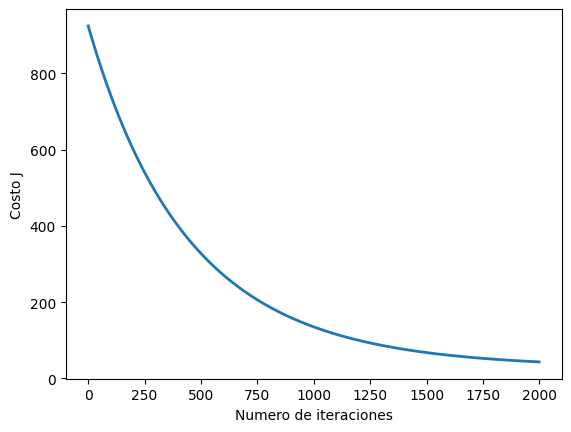

y real: 30.0
y pred: 23.670451296555278


In [34]:
# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show()

# Predicción rápida con el primer ejemplo
x0 = X[0]
x0_norm = (x0 - mu) / sigma
x0_ready = np.concatenate([[1], x0_norm])
y_pred = np.dot(x0_ready, theta)

print('y real:', y[0])
print('y pred:', y_pred)

### Predicciones del modelo lineal (10 ejemplos)

In [35]:
# (Inge) Si quieres ver varias predicciones rápidas:
print(np.round(np.dot(X_ready[:10], theta), 4))

[23.6705 31.0611 33.2142 38.5295  9.5916 76.4618  8.0564 20.4184 29.844
 26.9578]


## 2) Regresión polinómica (descenso por gradiente)

Se toma una característica base y se construyen potencias hasta grado 5 para entrenar un modelo polinómico con el mismo esquema vectorizado.

In [52]:
# Regresión polinómica (igual idea del inge: agregar x^2, x^3, ...)
nombre_columna_polinomica = 'O3 Promedio'
idx = list(df.columns[:-1]).index(nombre_columna_polinomica)

x_poly = X[:, idx]
grado = 5

X_poly = construirPolinomio(x_poly, grado)
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)

X_poly_ready = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 10000

theta_poly = np.zeros(X_poly_ready.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(X_poly_ready, y, theta_poly, alpha, num_iters)

print('Característica base (polinómica):', nombre_columna_polinomica)
print('theta polinómico:', theta_poly)
print('Costo final (polinómico):', J_history_poly[-1])

Característica base (polinómica): O3 Promedio
theta polinómico: [38.36383357  5.32606059  3.55560726  2.82486006  2.4862135   2.13795698]
Costo final (polinómico): 62.47547860238626


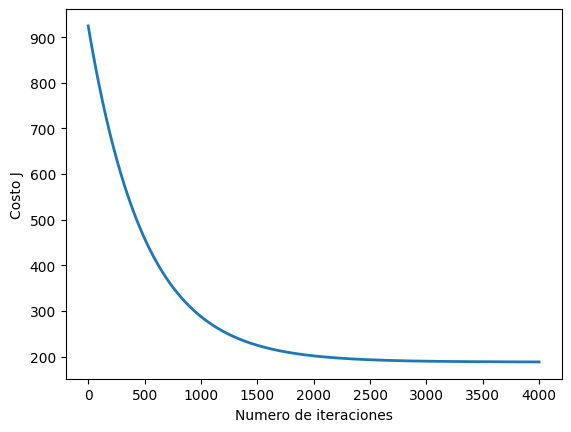

y real: 30.0
y pred (pol): 37.72668401025556


In [37]:
# Grafica la convergencia del costo (polinómico)
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show()

# Predicción rápida con el primer ejemplo
x0 = X[0, idx]
x0_poly = np.array([x0 ** i for i in range(1, grado + 1)])
x0_poly_norm = (x0_poly - mu_poly) / sigma_poly
x0_poly_ready = np.concatenate([[1], x0_poly_norm])
y_pred_poly = np.dot(x0_poly_ready, theta_poly)

print('y real:', y[0])
print('y pred (pol):', y_pred_poly)

### Predicciones del modelo polinómico (10 ejemplos)

In [38]:
print(np.round(np.dot(X_poly_ready[:10], theta_poly), 4))

[37.7267 37.6041 37.7645 37.7886 37.7267 37.752  37.7177 37.7577 37.7396
 37.7112]


## 3) Ecuación normal
Se calcula $\theta$ directamente con la ecuación normal (sin iteraciones). Sirve como referencia rápida frente al descenso por gradiente.

In [53]:
# Ecuación normal (igual que el inge)
X_normal = np.concatenate([np.ones((m, 1)), X], axis=1)

theta_normal = normalEqn(X_normal, y)
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_normal)))

y_pred_normal = np.dot(X_normal[0], theta_normal)
print('y real:', y[0])
print('y pred (normal):', y_pred_normal)

Theta calculado a partir de la ecuación de la normal: [-4.23128593e+01  1.36377614e-02  1.87444630e-01 -1.13966239e-02
 -6.75207221e-03  3.10848353e-03  1.80333842e-03 -2.79580617e+02
  1.52730575e+03  1.05821555e-01  4.83897807e-02 -4.49650509e+00
 -1.38997764e-02  4.53217633e-01  3.16412051e-03 -1.08834769e-01
  1.19603095e-02  1.33487489e-01 -4.85689277e-05 -7.68819554e-02
 -6.12637090e-02  8.71227757e-02]
y real: 30.0
y pred (normal): 28.70251485999666


In [40]:
print(np.round(np.dot(X_normal[:10], theta_normal), 4))

[28.9244 36.8796 36.9595 42.5518 11.9527 76.087  14.5645 31.2473 42.4039
 37.5165]
